In [24]:
import sys
!{sys.executable} -m pip install -q datasets polars 
"""
имею несколько ядер и основное системное Python 3.14 и есть проблемы с зависимостями 
на этой версии, поэтому через ядро conda base в jupiter
"""

from datasets import load_dataset

ds = load_dataset('irlspbru/RFSD', split='train', streaming=True)
print(len(ds.features))         
print(list(ds.features))

213
['inn', 'ogrn', 'region', 'region_taxcode', 'creation_date', 'dissolution_date', 'age', 'eligible', 'exemption_criteria', 'financial', 'filed', 'imputed', 'simplified', 'articulated', 'totals_adjustment', 'outlier', 'okved', 'okved_section', 'okpo', 'okopf', 'okogu', 'okfc', 'oktmo', 'lon', 'lat', 'geocoding_quality', 'line_1100', 'line_1110', 'line_1120', 'line_1130', 'line_1140', 'line_1150', 'line_1160', 'line_1170', 'line_1180', 'line_1190', 'line_1200', 'line_1210', 'line_1220', 'line_1230', 'line_1240', 'line_1250', 'line_1260', 'line_1300', 'line_1310', 'line_1320', 'line_1340', 'line_1350', 'line_1360', 'line_1370', 'line_1400', 'line_1410', 'line_1420', 'line_1430', 'line_1450', 'line_1500', 'line_1510', 'line_1520', 'line_1530', 'line_1540', 'line_1550', 'line_1600', 'line_1700', 'line_2100', 'line_2110', 'line_2120', 'line_2200', 'line_2210', 'line_2220', 'line_2300', 'line_2310', 'line_2320', 'line_2330', 'line_2340', 'line_2350', 'line_2400', 'line_2410', 'line_2411', 

In [32]:
"""Выводить только первые 20 нет смысла, так как там много просто метаданных, а в line_XXXX уже строки бухгалтерских форм (https://github.com/irlcode/RFSD/blob/main/aux_data/descriptive_names_dict.csv).  
И так как есть в use_cases на гите исследование о процентном канале денежной политики(показатель кредитоспособности), то для того чтобы не повторятся можно взять немного иные столбцы 
"""

cols = [
        "inn", "region", "okved_section", "age", "filed", "outlier",
        "line_1150", "line_1200", "line_1210", "line_1230",
        "line_1250", "line_1300", "line_1400", "line_1500", "line_1600",
        "line_2110", "line_2120", "line_2330", "line_2300", "line_2400"
    ]

cols = [c for c in cols if c in ds.features]
len(cols)   

20

In [34]:
import polars as pl

sample = ds.select_columns(cols).take(1000)
df = pl.DataFrame(list(sample))

df.shape 

print(df.shape)
print(df.null_count())

(1000, 20)
shape: (1, 20)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ inn ┆ reg ┆ okv ┆ age ┆ fil ┆ out ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin ┆ lin │
│ --- ┆ ion ┆ ed_ ┆ --- ┆ ed  ┆ lie ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_1 ┆ e_2 ┆ e_2 ┆ e_2 ┆ e_2 ┆ e_2 │
│ u64 ┆ --- ┆ sec ┆ u64 ┆ --- ┆ r   ┆ 150 ┆ 200 ┆ 210 ┆ 230 ┆ 250 ┆ 300 ┆ 400 ┆ 500 ┆ 600 ┆ 110 ┆ 120 ┆ 330 ┆ 300 ┆ 400 │
│     ┆ u64 ┆ tio ┆     ┆ u64 ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│     ┆     ┆ n   ┆     ┆     ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 ┆ u64 │
│     ┆     ┆ --- ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     │
│     ┆     ┆ u64 ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     

In [44]:
names = pl.read_csv(
    "https://raw.githubusercontent.com/irlcode/RFSD/main/aux_data/descriptive_names_dict.csv"
)
df = df.rename({o: d for o, d in zip(names["original"], names["descriptive"]) if o in df.columns})
df.columns

['inn',
 'region',
 'okved_section',
 'age',
 'filed',
 'outlier',
 'B_fixed_assets',
 'B_current_assets',
 'B_inventories',
 'B_accounts_receivable',
 'B_cash_equivalents',
 'B_total_equity',
 'B_longterm_liab',
 'B_shortterm_liab',
 'B_assets',
 'PL_revenue',
 'PL_cost_of_sales',
 'PL_interest_payable',
 'PL_before_tax',
 'PL_net_profit']

In [50]:
pl.Config.set_tbl_cols(25)
pl.Config.set_fmt_float("full")

df.describe()

statistic,inn,region,okved_section,age,filed,outlier,B_fixed_assets,B_current_assets,B_inventories,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_longterm_liab,B_shortterm_liab,B_assets,PL_revenue,PL_cost_of_sales,PL_interest_payable,PL_before_tax,PL_net_profit
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""1000""","""1000""","""908""",1000,1000,1000,234,331,269,217,227,328,79,292,340,271,277,54,296,296
"""null_count""","""0""","""0""","""92""",0,0,0,766,669,731,783,773,672,921,708,660,729,723,946,704,704
"""mean""",null,null,null,6.595,0,0,13379.92735042735,17565.767371601207,9596.078066914499,13142.414746543778,673.8414096916299,7434.975609756098,26432.189873417723,18154.739726027397,28912.620588235295,36925.243542435426,-33145.11913357401,-6896.074074074074,523.2398648648649,398.9695945945946
"""std""",null,null,null,4.784544583015908,0,0,43709.45329979811,101673.53950223424,34421.872979806205,83460.31960493962,3688.446467880379,26794.77921658356,53263.03800806053,111486.17675982566,135411.64012969393,205008.19632192783,190874.20696405275,17761.33526857458,6395.40408550125,5672.892773779634
"""min""","""0100000036""","""adygeya""","""A""",0,0,0,2,1,1,1,1,-39077,1,1,1,7,-2971014,-122471,-33443,-32644
"""25%""",null,null,null,3,0,0,19,198,170,76,5,15,741,91,232,1576,-12022,-4262,3,0
"""50%""",null,null,null,5,0,0,258,780,548,698,15,314,6166,468,932,4435,-4094,-941,83,67
"""75%""",null,null,null,10,0,0,4706,4453,3488,3422,136,2164,29076,4167,8023,13918,-1300,-226,526,427
"""max""","""0104012480""","""udmurtia""","""S""",26,0,0,521931,1650913,309681,1177298,52847,188932,371010,1724946,2172844,3111601,-5,-14,76431,59175


Вывод по описательной статистике. Данные разрежены, и это свойство самой отчётности. Значительная часть финансовых строк пуста.




Гистограммы трёх колонок.

Выбраны выручка (`PL_revenue`), собственный капитал (`B_total_equity`) и возраст фирмы(`age`).
Выручка почти наверняка покажет тяжёлые хвосты, собственный капитал может быть отрицательным (техническое банкротство, когда обязательства превышают активы), а для возраста отрицательные значения были бы явной ошибкой ввода.

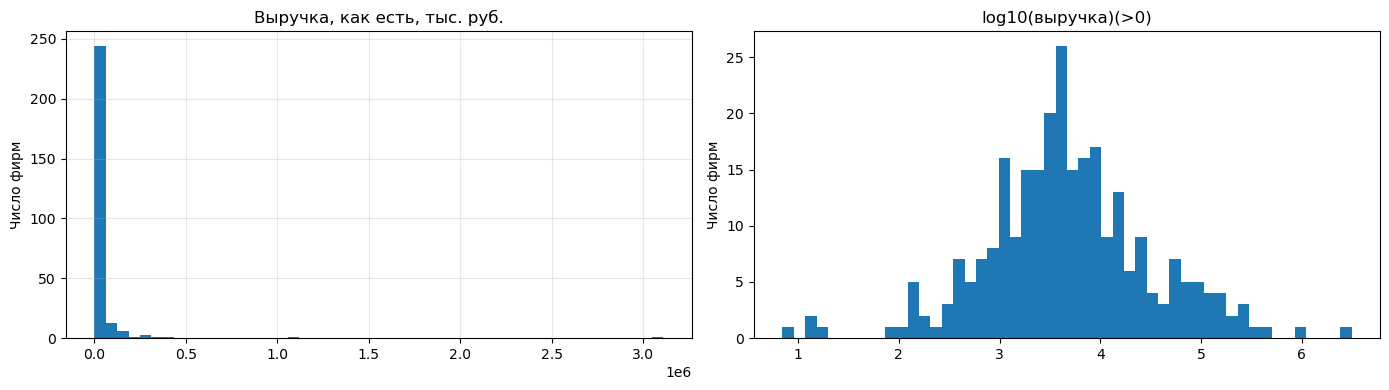

нулевая выручка: 0 из 271
отрицательная:   0
среднее / медиана = 8.3


In [76]:
#анализ выручки
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (14, 4)

def clean(col):
    return df[col].drop_nulls().to_numpy()
    
rev = clean("PL_revenue")
pos = rev[rev > 0] 

fig, ax = plt.subplots(1, 2)
ax[0].hist(rev, bins=50); ax[0].set_title("Выручка, как есть, тыс. руб."); ax[0].set_ylabel("Число фирм"); ax[0].grid(alpha=0.3)
ax[1].hist(np.log10(pos), bins=50); ax[1].set_title("log10(выручка)(>0)"); ax[1].set_ylabel("Число фирм")
plt.tight_layout(); plt.show()

print(f"нулевая выручка: {(rev == 0).sum()} из {len(rev)}")
print(f"отрицательная:   {(rev < 0).sum()}")
print(f"среднее / медиана = {rev.mean() / np.median(rev):.1f}")

Гистограмма в исходном масштабе нечитаема, так почти все фирмы попадают в первый столбик, а ось растянута до миллионов из-за единичных наблюдений справа. Поэтому log. И из полученных результатов выручка распределена логнормально. Нулевых и отрицательных значений выручки
не обнаружено.

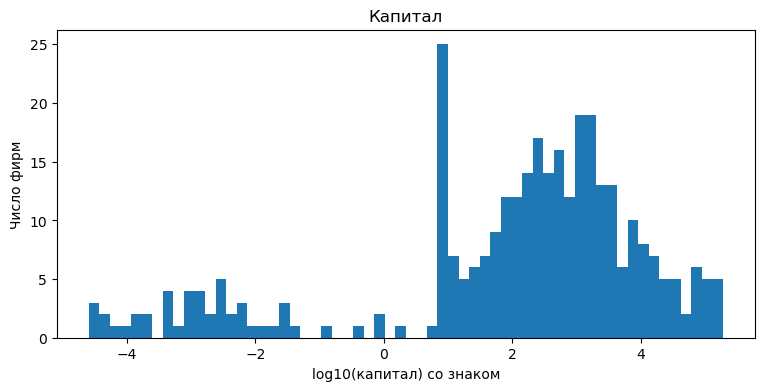

In [90]:
#анализ значения собственного капитала
eq = clean("B_total_equity") 
plt.figure(figsize=(9, 4))
plt.hist(np.log10(np.abs(eq[eq != 0])) * np.sign(eq[eq != 0]), bins=60)
plt.title("Капитал")
plt.xlabel("log10(капитал) со знаком"); plt.ylabel("Число фирм")
plt.show()

Имеется отрицательный капитал. Но это может быть признаком банкротства предприятия, когда долговых обязательств много.

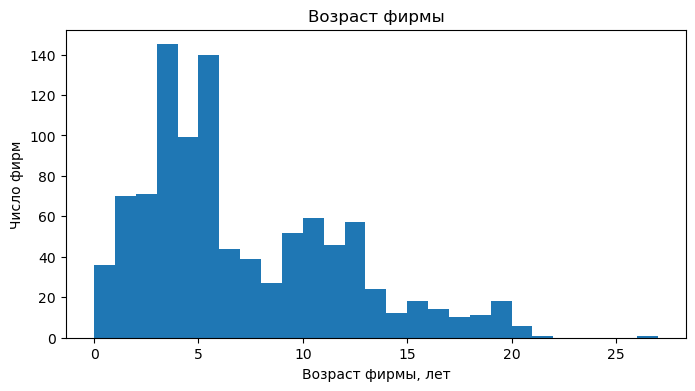

диапазон возраста фирм 0.0 – 26.0
возраст 0 36
возраст меньше нуля 0


In [129]:
#анализ возраста фирмы 
age = clean("age")
plt.figure(figsize=(8, 4))
plt.hist(age, bins=range(int(age.min()), int(age.max()) + 2))
plt.title("Возраст фирмы"); plt.xlabel("Возраст фирмы, лет"); plt.ylabel("Число фирм")
plt.show()

print(f"диапазон возраста фирм {age.min()} – {age.max()}")
print(f"возраст 0 {(age == 0).sum()}")
print(f"возраст меньше нуля {(age < 0).sum()}")

Отрицательных значений возраста в срезе не обнаружено.

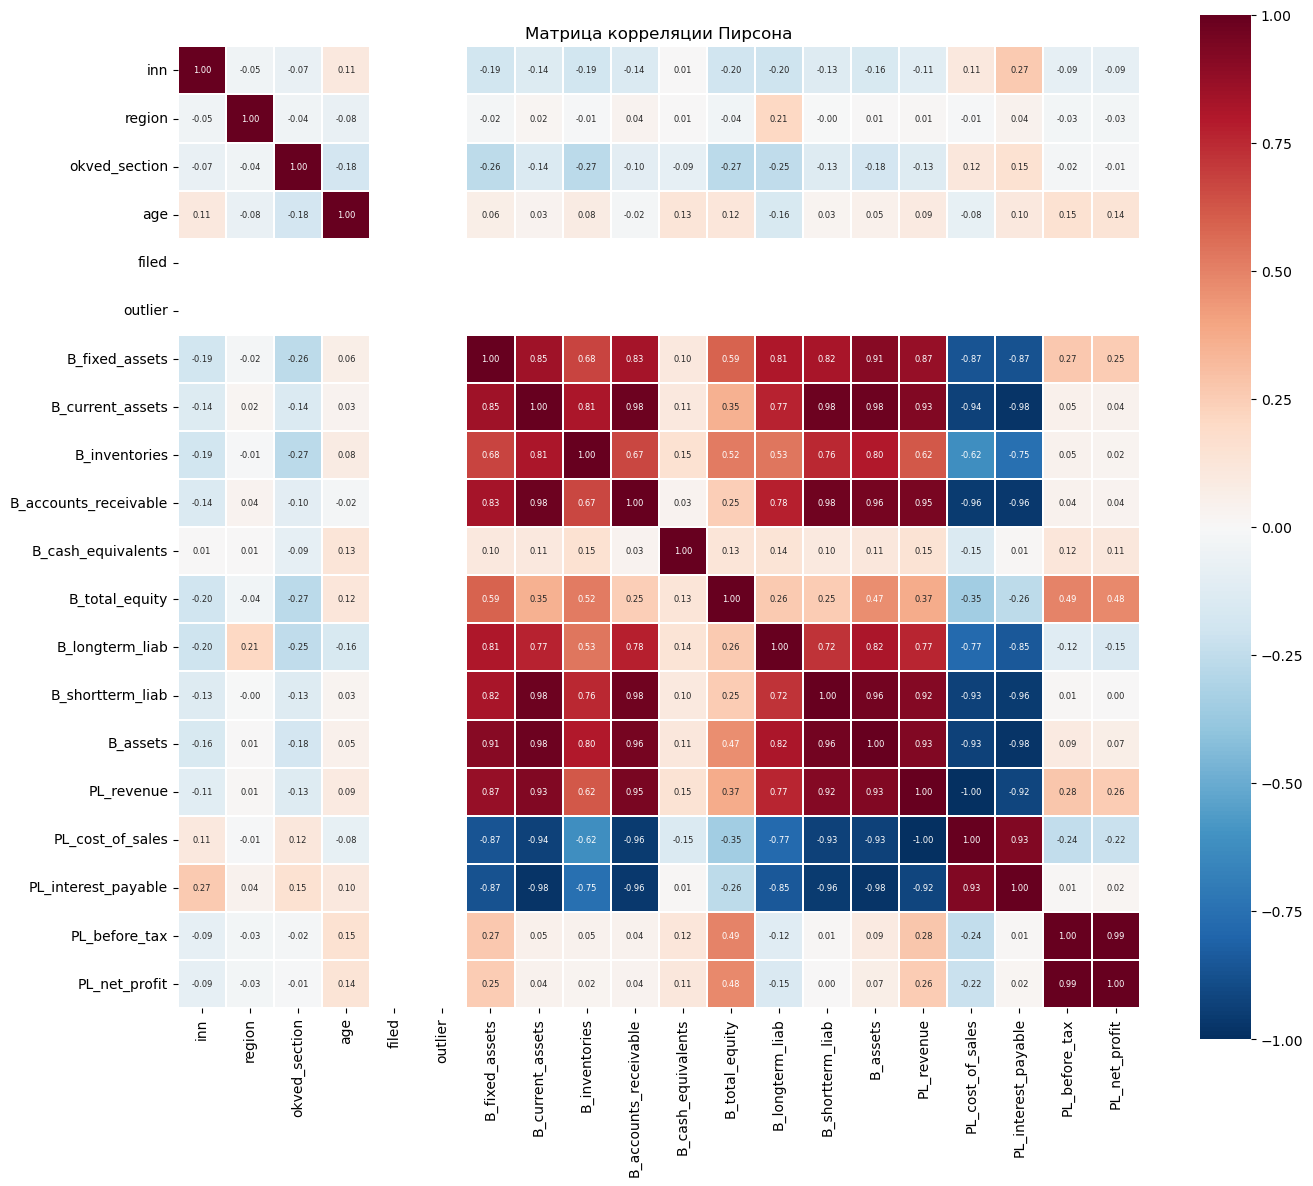

In [147]:
#Здесь просто через критерий Пирсона(без дополнений)
import seaborn as sns

pdf = df.to_pandas()
for c in pdf.columns:
    if pdf[c].dtype == object:
        pdf[c] = pdf[c].astype("category").cat.codes

corr = pdf.corr(method="pearson")
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"size": 6}, linewidths=0.3)
plt.title("Матрица корреляции Пирсона")
plt.tight_layout(); plt.show()

Строки filed и outlier в матрице пусты.В данном срезе они константны.Высокие значения между PL_before_tax и PL_net_profit
(0.99), потому что это одна и та же величина. Между PL_revenue и PL_cost_of_sales -1.00, что такого быть не может. Выручка растянута на пять
порядков. Единственной парой, где корреляция говорит что-то неочевидное является B_fixed_assets и B_longterm_liab (около 0.81), что говрит о том что основные средства финансируются кредитами и фирмы в срезе имеют кредиты.

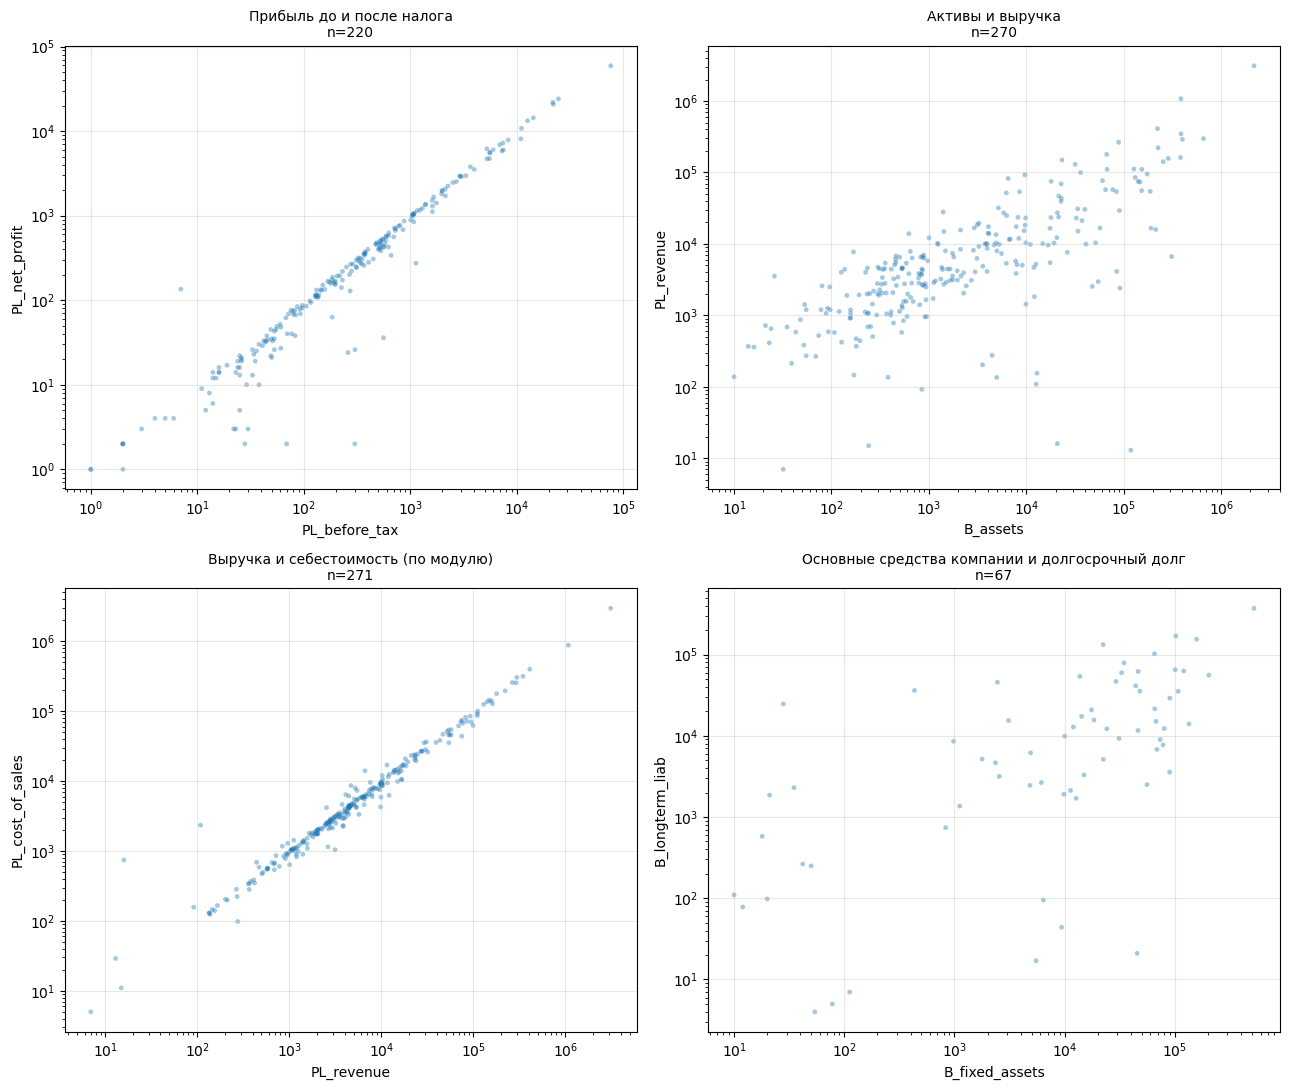

In [172]:
#Здесь в лог-масштабе пришлось, так как данные "забивались" в угол,а так хоть более видно
pdf = df.to_pandas()
pdf["PL_cost_of_sales"] = pdf["PL_cost_of_sales"].abs()
pdf["PL_interest_payable"] = pdf["PL_interest_payable"].abs()

pairs = [
    ("PL_before_tax",  "PL_net_profit",   "Прибыль до и после налога"),
    ("B_assets",       "PL_revenue",      "Активы и выручка"),
    ("PL_revenue",     "PL_cost_of_sales","Выручка и себестоимость (по модулю)"),
    ("B_fixed_assets", "B_longterm_liab", "Основные средства компании и долгосрочный долг"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (x, y, title) in zip(axes.flat, pairs):
    d = pdf[[x, y]].dropna()
    d = d[(d[x] > 0) & (d[y] > 0)]
    ax.scatter(d[x], d[y], s=12, alpha=0.4, edgecolors="none")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"{title}\nn={len(d)}", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

В результе на первой панели разброс минимальный. На второй облако вытянутое и широкое получилось, что говорит об различия[ в эффективности между фирмами. Третья панель ближе к прямой. На четвёртой самый большой разброс и лишь небольшое количество наблюдений из 1000.